In [1]:
import sys
sys.path.append('..')
from common_helper_functions import *

In [2]:
path = "../../../../../../../../../../s/project/yeast_gxg/data/orthrus_data/"
protein_localization = np.load( path + 'protein_localization_dataset.npz')

In [3]:
investigate_dataset(protein_localization)

['X', 'y', 'genes']

Array shapes:
X shape: (9769, 12288, 6)
y shape: (9769, 12)
genes shape: (9769,)

First few y values: [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]

X dimensions: 3
X first sample shape: (12288, 6)
X first sample, first feature vector: [0. 0. 1. 0. 0.]


In [4]:
pca_embeddings = create_embedding_dataframe(protein_localization['X'], protein_localization['genes'])
pca_embeddings

PCA embeddings shape: (9769, 2048)
Total explained variance by PCA 65.05%


,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2038,PCA_2039,PCA_2040,PCA_2041,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047
gene_id,,,,,,,,,,,,,,,,,,,,,
C1orf112,9.856798,-3.786797,17.809664,9.046407,-4.545287,1.064800,-10.574132,-3.584323,-7.779896,4.624073,...,-0.449448,0.999137,0.473877,0.561048,-1.089374,1.499420,0.237131,-0.228026,-0.547575,2.091694
FGR,-10.732239,16.028515,-5.621181,-0.390495,0.573718,-7.165555,-3.193029,0.394370,5.179955,1.700026,...,-0.649610,-0.054071,-0.926820,0.516245,-0.276441,-0.409804,-0.326412,-0.140172,0.054514,-0.203220
CFH,7.006868,23.785175,-7.232403,9.518152,5.969955,5.529424,2.496709,-2.940991,-10.176314,6.325758,...,-1.509295,-0.951797,-0.002186,0.427255,1.638197,0.030997,1.155592,-1.246290,-0.123349,0.664157
GCLC,3.741449,16.818596,-5.728704,10.611556,1.750892,1.134919,0.392556,2.120402,-4.206462,-1.344807,...,-0.308723,0.144599,0.315682,0.618134,-0.418675,0.648448,-0.666965,-0.481633,-0.208713,-1.039300
NFYA,16.261385,-2.448750,11.577386,-1.681725,-6.337146,6.196477,9.162161,2.846485,6.783443,-1.467570,...,0.779510,-0.256564,-0.522535,-0.488848,0.042694,-1.396275,-0.745611,0.625830,-0.327902,0.231924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H2AC18,-16.164528,-0.711230,3.695416,-9.967198,-3.283584,2.942060,5.236429,-5.229249,-4.926538,-3.050584,...,-0.017957,-0.249696,0.005688,0.116703,-0.088455,0.252035,0.166339,0.062215,0.194745,0.197325
H2AC19,-16.295773,-2.631325,-1.827519,-9.977579,-2.929593,5.729000,-1.170313,-5.806081,-4.658218,-2.984190,...,-0.210343,-0.186504,0.157841,-0.037402,-0.180549,0.556327,-0.398199,-0.042799,0.038030,0.090279
ENSG00000289346,9.783045,15.399920,-5.534424,8.447047,9.947762,11.428389,5.757548,-8.421619,-7.163854,1.605456,...,0.326745,-0.943042,-0.563194,-0.267788,-1.798514,0.591531,1.415165,0.043933,-0.014839,-0.468826


In [5]:
emogi_predictions = pd.read_csv('../../../../../../../../s/project/gene_embedding/input_data/cancer_eval/emogi_predictions.tsv', sep='\t')
emogi_predictions

,ID,Name,label,Prob_pos_1,Prob_pos_2,Prob_pos_3,Prob_pos_4,Prob_pos_5,Prob_pos_6,Prob_pos_7,...,Prob_pos_9,Prob_pos_10,Num_Pos,Mean_Pred,Std_Pred,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene,ONGene_Oncogene
0,ENSG00000100393,EP300,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
1,ENSG00000133703,KRAS,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
2,ENSG00000155657,TTN,False,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,False,True,False,False,False
3,ENSG00000284792,PTEN,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,False
4,ENSG00000039068,CDH1,True,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,10,1.0,0.0,True,False,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13622,ENSG00000266200,PNLIPRP2,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13623,ENSG00000125375,DMAC2L,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13624,ENSG00000173662,TAS1R1,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False
13625,ENSG00000197084,LCE1C,False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,0.0,0.0,False,False,False,False,False


In [ ]:
cancer_gene_columns = emogi_predictions[['Name', "NCG_Known_Cancer_Gene", "NCG_Candidate_Cancer_Gene", "OncoKB_Cancer_Gene", "Bailey_et_al_Cancer_Gene"]]
merged = pca_embeddings.merge(cancer_gene_columns, left_index=True, right_on='Name', how='inner')
merged.set_index('Name', inplace=True)
merged

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8,PCA_9,...,PCA_2042,PCA_2043,PCA_2044,PCA_2045,PCA_2046,PCA_2047,NCG_Known_Cancer_Gene,NCG_Candidate_Cancer_Gene,OncoKB_Cancer_Gene,Bailey_et_al_Cancer_Gene
Name,,,,,,,,,,,,,,,,,,,,,
FGR,-10.732239,16.028515,-5.621181,-0.390495,0.573718,-7.165555,-3.193029,0.394370,5.179955,1.700026,...,-0.276441,-0.409804,-0.326412,-0.140172,0.054514,-0.203220,False,False,False,False
CFH,7.006868,23.785175,-7.232403,9.518152,5.969955,5.529424,2.496709,-2.940991,-10.176314,6.325758,...,1.638197,0.030997,1.155592,-1.246290,-0.123349,0.664157,False,False,False,False
GCLC,3.741449,16.818596,-5.728704,10.611556,1.750892,1.134919,0.392556,2.120402,-4.206462,-1.344807,...,-0.418675,0.648448,-0.666965,-0.481633,-0.208713,-1.039300,False,False,False,False
NFYA,16.261385,-2.448750,11.577386,-1.681725,-6.337146,6.196477,9.162161,2.846485,6.783443,-1.467570,...,0.042694,-1.396275,-0.745611,0.625830,-0.327902,0.231924,False,False,False,False
NIPAL3,12.457924,12.926982,-4.908123,4.092911,-9.950997,0.875625,-0.442008,-0.215989,5.599617,-2.671823,...,0.650205,1.415623,1.021218,0.380604,-1.952049,-1.115880,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACACA,30.513531,-20.624279,-19.247835,-18.139866,2.921804,-19.265057,9.514173,3.320822,-7.482876,1.156726,...,-0.127533,0.686494,0.091201,-0.876768,-0.937018,0.092171,False,False,False,False
MRM1,-12.605599,11.342134,-3.682305,-3.019351,-2.136310,-6.592063,-3.053613,-0.243786,4.935533,-0.558522,...,-0.176542,0.170694,-0.214489,0.045860,-0.603084,0.600265,False,False,False,False
MRPL45,-14.170598,-2.042840,9.330525,-6.103000,0.368492,1.470641,8.085276,-0.145138,-0.400853,1.473263,...,0.705984,0.216457,0.352865,-0.462541,0.015061,-0.215212,False,False,False,False


## Predict NCG_Known_Cancer_Gene

In [7]:
merged['NCG_Known_Cancer_Gene'].value_counts()

NCG_Known_Cancer_Gene
False    6815
True      419
Name: count, dtype: int64

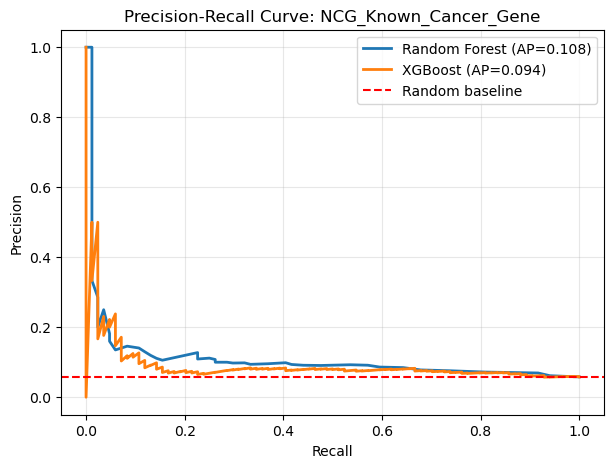

Random Forest - auPRC: 0.108
XGBoost - auPRC: 0.094



In [8]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'Bailey_et_al_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'NCG_Known_Cancer_Gene')

## NCG_Candidate_Cancer_Gene

In [9]:
merged['NCG_Candidate_Cancer_Gene'].value_counts()

NCG_Candidate_Cancer_Gene
False    6580
True      654
Name: count, dtype: int64

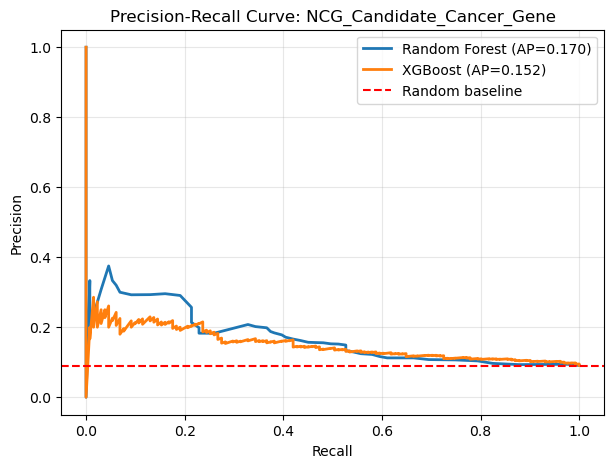

Random Forest - auPRC: 0.170
XGBoost - auPRC: 0.152



In [10]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'NCG_Candidate_Cancer_Gene')

## OncoKB_Cancer_Gene

In [11]:
merged['OncoKB_Cancer_Gene'].value_counts()

OncoKB_Cancer_Gene
False    6901
True      333
Name: count, dtype: int64

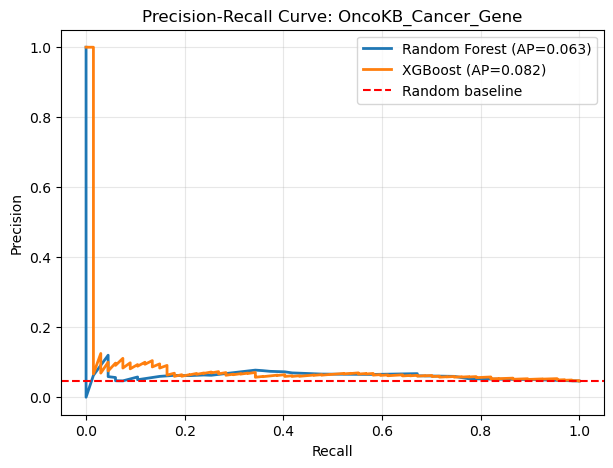

Random Forest - auPRC: 0.063
XGBoost - auPRC: 0.082



In [12]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'Bailey_et_al_Cancer_Gene']), 'OncoKB_Cancer_Gene')

## Bailey_et_al_Cancer_Gene

In [13]:
merged['Bailey_et_al_Cancer_Gene'].value_counts()

Bailey_et_al_Cancer_Gene
False    7067
True      167
Name: count, dtype: int64

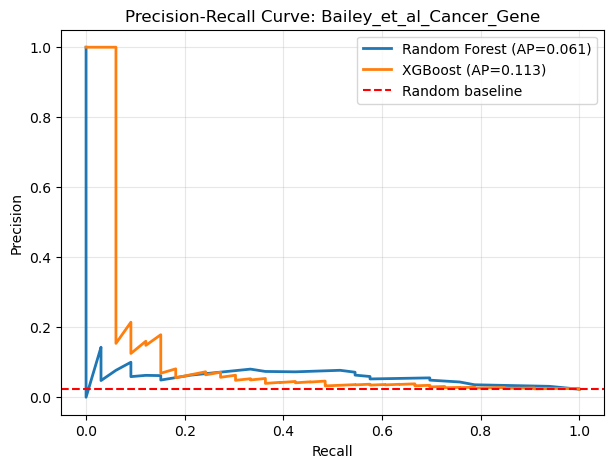

Random Forest - auPRC: 0.061
XGBoost - auPRC: 0.113



In [14]:
predict_and_plot_pr_curve(merged.drop(columns=['NCG_Candidate_Cancer_Gene', 'NCG_Known_Cancer_Gene', 'OncoKB_Cancer_Gene']), 'Bailey_et_al_Cancer_Gene')